In [17]:
print('test')
CSV_FILE = "./04_velocity_slice_k.csv"
CSV_FILE2 = "./04_velocity_slice_2k.csv"

test


0.055555555555555546
0.055763007317664086
1.0037341317179538


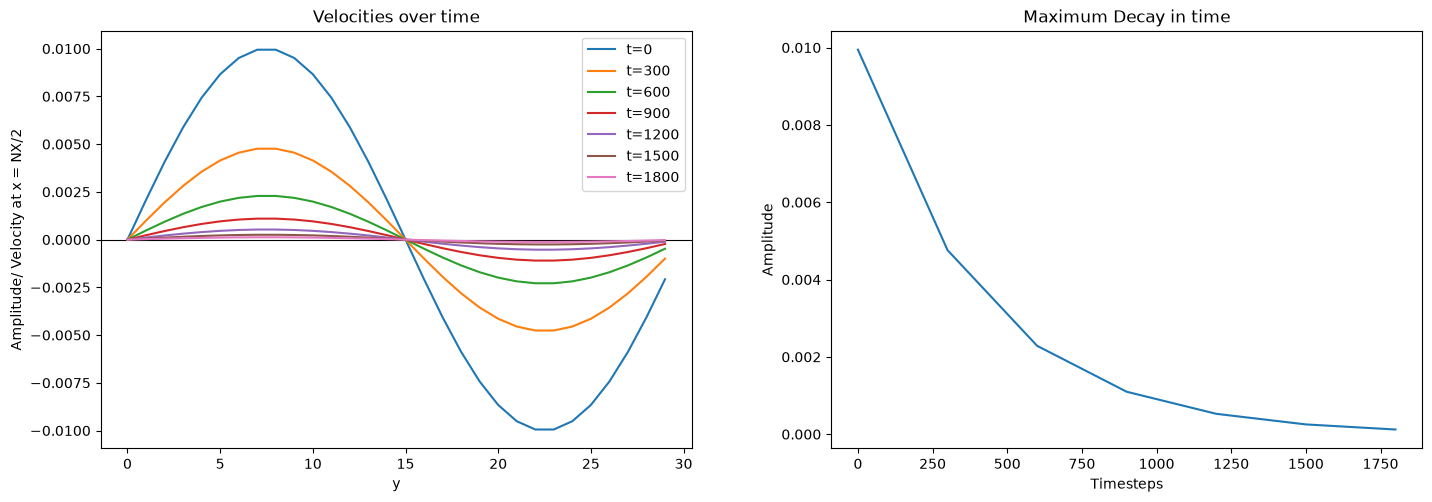

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Index(['timestep', 'y', 'velocity_value'], dtype='object')
df = pd.read_csv(CSV_FILE)
df2 = pd.read_csv(CSV_FILE2)


timesteps = sorted(df["timestep"].unique())
#fig, (ax1, ax2, ax3) = plt.subplots(1, 3, width_ratios=[1 / 3, 1/ 3, 1 / 3])
fig, (ax1, ax2) = plt.subplots(1, 2, width_ratios=[1 / 2, 1/ 2])

fig.tight_layout(pad=1.2)
fig.set_figwidth(10)

ax1.set_title("Velocities over time")
ax1.set_xlabel("y")
ax1.set_ylabel("Amplitude/ Velocity at x = NX/2")

# ax2.set_title("Velocities over time")
# ax2.set_xlabel("y")
# ax2.set_ylabel("Amplitude/ Velocity at x = NX/2")


sax1 = ax1.secondary_xaxis(0, transform=ax1.transData)
sax1.set_ticks([])


# sax2 = ax2.secondary_xaxis(0, transform=ax1.transData)
# sax2.set_ticks([])


for timestep in timesteps:
    subset = df[df["timestep"] == timestep].sort_values("y")
    ax1.plot(subset["y"], subset["velocity_value"], label=f"t={timestep}")
    # subset2 = df2[df2["timestep"] == timestep].sort_values("y")
    # ax2.plot(subset2["y"], subset2["velocity_value"], label=f"t={timestep}")



ax1.legend()
# ax2.legend()
decay_ax = ax2

decay_ax.set_title("Maximum Decay in time")
decay_ax.set_xlabel("Timesteps")
decay_ax.set_ylabel("Amplitude")

max_y = df.loc[df["timestep"] == 0, "velocity_value"].idxmax()
#max_y2 = df.loc[df["timestep"] == 0, "velocity_value"].idxmax()

y_argmax = df.loc[max(max_y, max_y2), "y"]

subset = df[df["y"] == y_argmax]
decay_ax.plot(subset["timestep"], subset["velocity_value"], )

#subset2 = df2[df2["y"] == y_argmax]
#decay_ax.plot(subset2["timestep"], subset2["velocity_value"], )

SIZE_Y = max(df["y"]) + 1
OMEGA = np.double(1.5)
k = 2 * np.divide(np.pi, SIZE_Y);

analytical_viscocity = np.divide(np.divide(1, OMEGA) - 0.5 , 3)
viscocity = np.divide(-slope, np.square(k))

print(analytical_viscocity)
print(viscocity)
print(np.divide(viscocity, analytical_viscocity))


plt.show()